In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

In [2]:
def symmetric_matrix(theta):
    # Determine the size of the symmetric matrix
    n = int((np.sqrt(1 + 8 * len(theta)) - 1) / 2)  # Solve n * (n + 1) / 2 = len(theta)
    if len(theta) != n * (n + 1) // 2:
        raise ValueError("Size of theta is invalid for a symmetric matrix")
    # Create an empty matrix
    matrix = np.zeros((n, n))
    # Get the indices for the upper triangular part (including the diagonal)
    triu_indices = np.triu_indices(n)
    # Assign values to the upper triangular part
    matrix[triu_indices] = theta
    # Mirror the upper triangular part to the lower triangular part
    matrix = matrix + matrix.T - np.diag(np.diag(matrix))
    return np.matrix(matrix)

def extract_theta(symmetric_matrix):
    # Ensure input is a square matrix
    if symmetric_matrix.shape[0] != symmetric_matrix.shape[1]:
        raise ValueError("Input must be a square matrix")
    # Extract the upper triangular part (including the diagonal)
    triu_indices = np.triu_indices(symmetric_matrix.shape[0])
    theta = symmetric_matrix[triu_indices]
    return np.array(theta).flatten()

In [3]:
def meta_int(X, t, betat, gamma, mu, Na):
    S = X[:3]
    I = X[3:6]
    Theta = X[6:]
    beta = betat(t)
    Inf = np.matmul(I/Na,beta)

    dS = -Inf*S + (Na-S)*mu
    dI = Inf*S - (gamma+mu)*I
    S = S/Na
    I = I/Na

    N = np.array([Na,Na,Na])
    J_ss = np.diag([-mu,-mu,-mu])
    J_si = -beta * N[:, np.newaxis]
    J_is = np.diag([0,0,0])
    J_ii = -(mu+gamma)*np.eye(3) + beta * N[:, np.newaxis]
    A = np.block([[J_ss,J_si],[J_is,J_ii]])

    B_ss = np.diag([mu*(1-N[0]),mu*(1-N[1]),mu*(1-N[2])])
    B_si = np.diag([0,0,0])
    B_ii = np.diag([0,0,0])
    B = np.block([[B_ss,B_si],[B_si,B_ii]])

    Θ = symmetric_matrix(Theta)
    K = A*Θ+Θ*A.transpose()+B
    return np.concatenate([dS,dI,extract_theta(K)])

$R_0=1/(\gamma+\mu)*\rho(\beta)$

In [4]:
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
b_w = 0.231  # Transmission within each city
b_b = 0.12 # Transmission between cities
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
np.max(np.linalg.eigvals(beta_matrix))/(gamma+mu)

4.005684465099393

## Constant $\beta$

In [5]:
# Parameters
N_cities = 3   # Number of cities
T_max = 100    # Maximum time
b_w = 0.231  # Transmission within each city
b_b = 0.12 # Transmission between cities
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
N_population = 100000  # Population per city

Ii = np.array([100,100,100])
Si = N_population - Ii

betat = lambda t: beta_matrix

ts = np.arange(0,100.1,0.1)
cst_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(cst_theory[i,6:])[3:,3:] for i in range(len(ts))]
cst_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(cst_theory[i,:3]*beta_matrix)) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_213503/3860749001.py:20: RuntimeWarning: invalid value encountered in scalar divide
  cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([272]),)

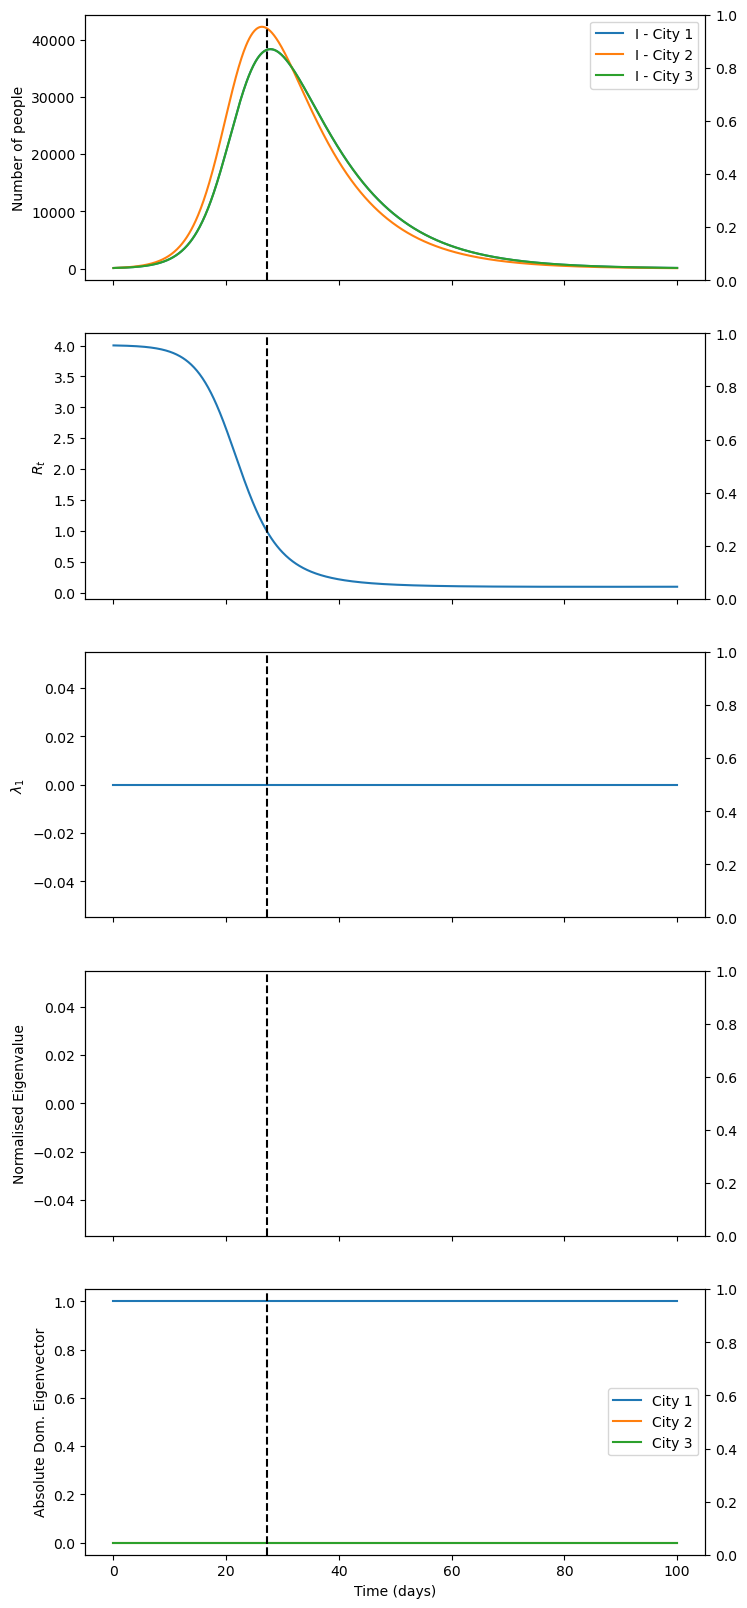

In [6]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,cst_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(cst_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,cst_eigvals)
axs[3].plot(ts,cst_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Just b[1,1], full epidemic

In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])

ts = np.arange(0,100.1,0.1)
in_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(in_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
in_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(in_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_145949/241139304.py:19: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([294]),)

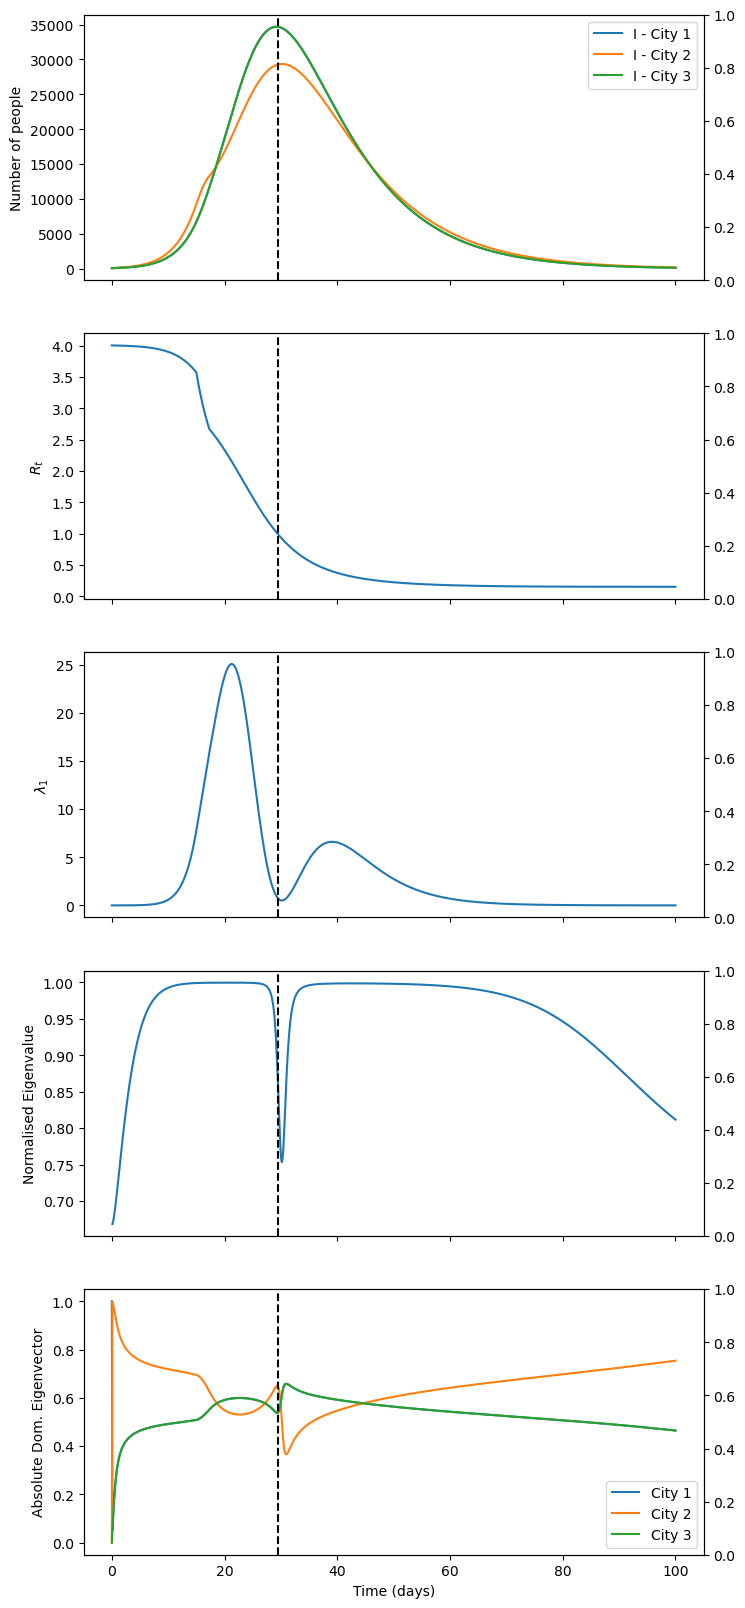

In [410]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,in_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(in_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,in_dec_eigvals)
axs[3].plot(ts,in_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Between cities

In [411]:
def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

ts = np.arange(0,100.1,0.1)
bet_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(bet_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
bet_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(bet_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/1117251583.py:12: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([344, 345]),)

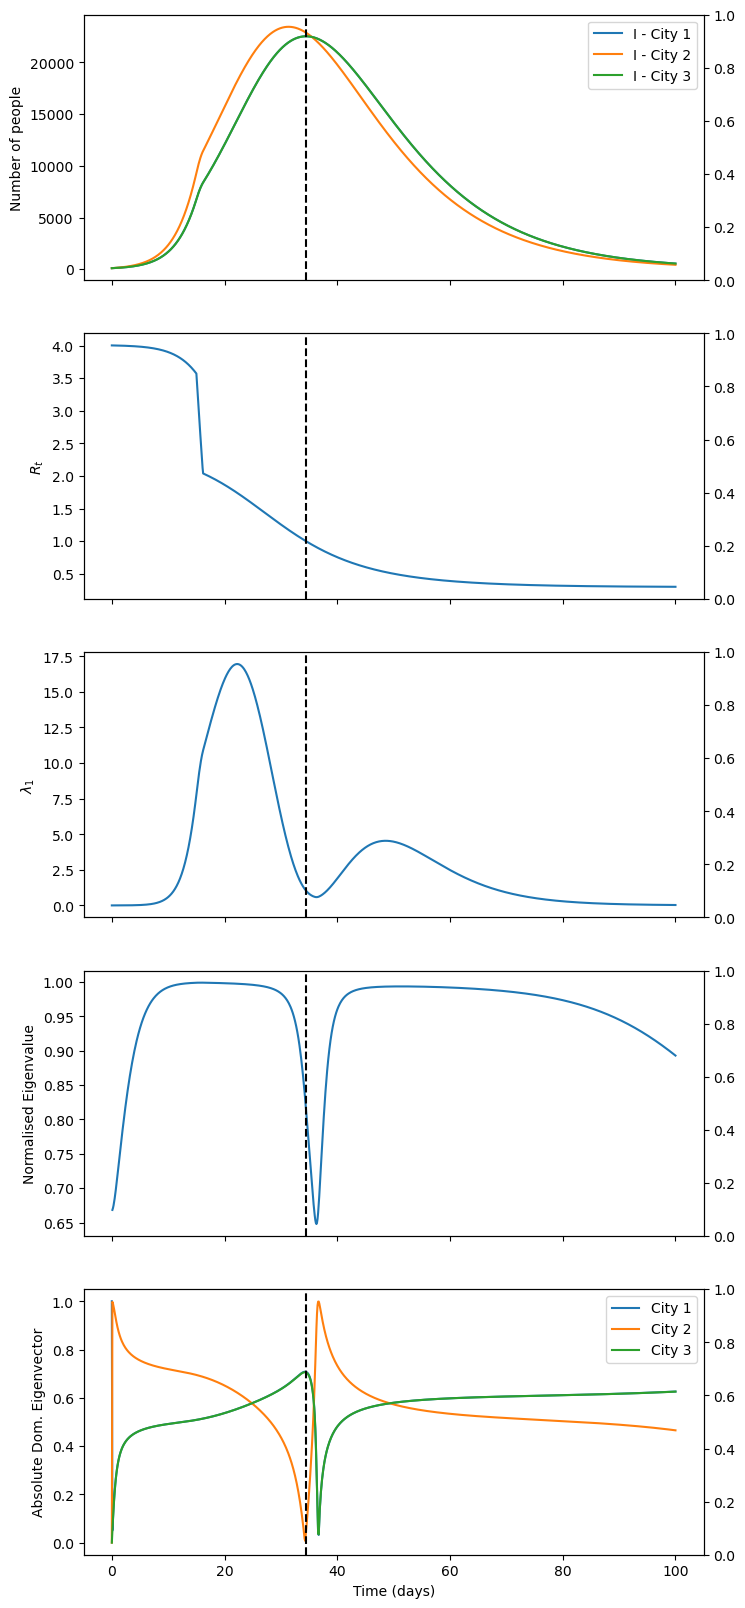

In [412]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,bet_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(bet_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,bet_dec_eigvals)
axs[3].plot(ts,bet_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## New variant

In [413]:
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
b_w_l = 0.05  # Transmission within each city
b_b_l = 0.025 # Transmission between cities
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu)

0.8532611778611298


1.3303954541400647

In [414]:
def betat(t):
    if t < 15:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],[0,0,1],[0,0,1]])
        return beta_matrix_low + 0.01*(t-15)*temp

ts = np.arange(0,100.1,0.1)
spur_var_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(spur_var_theory[i,6:])[3:,3:] for i in range(len(ts))]
spur_var_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(spur_var_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/3905541819.py:12: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([170, 587]),)

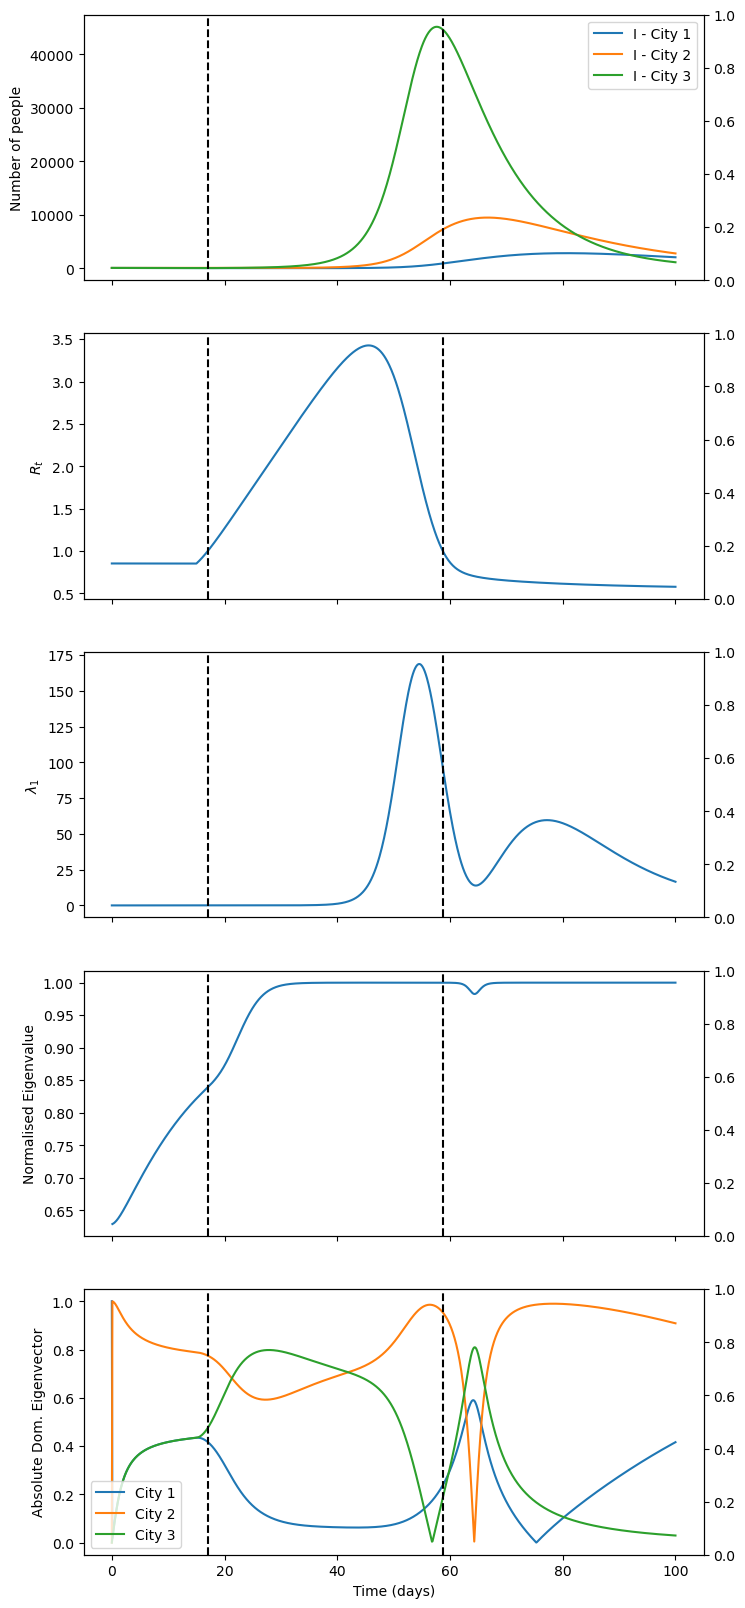

In [415]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,spur_var_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(spur_var_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,spur_var_eigvals)
axs[3].plot(ts,spur_var_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

# Earlier NPIs

## Just b[1,1], full epidemic

In [416]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

def betat(t):
    if t < 5:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.1*(t-5)*temp if (beta_matrix - 0.1*(t-5)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])

ts = np.arange(0,100.1,0.1)
in_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(in_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
in_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(in_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_145949/1449569307.py:19: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([332, 333]),)

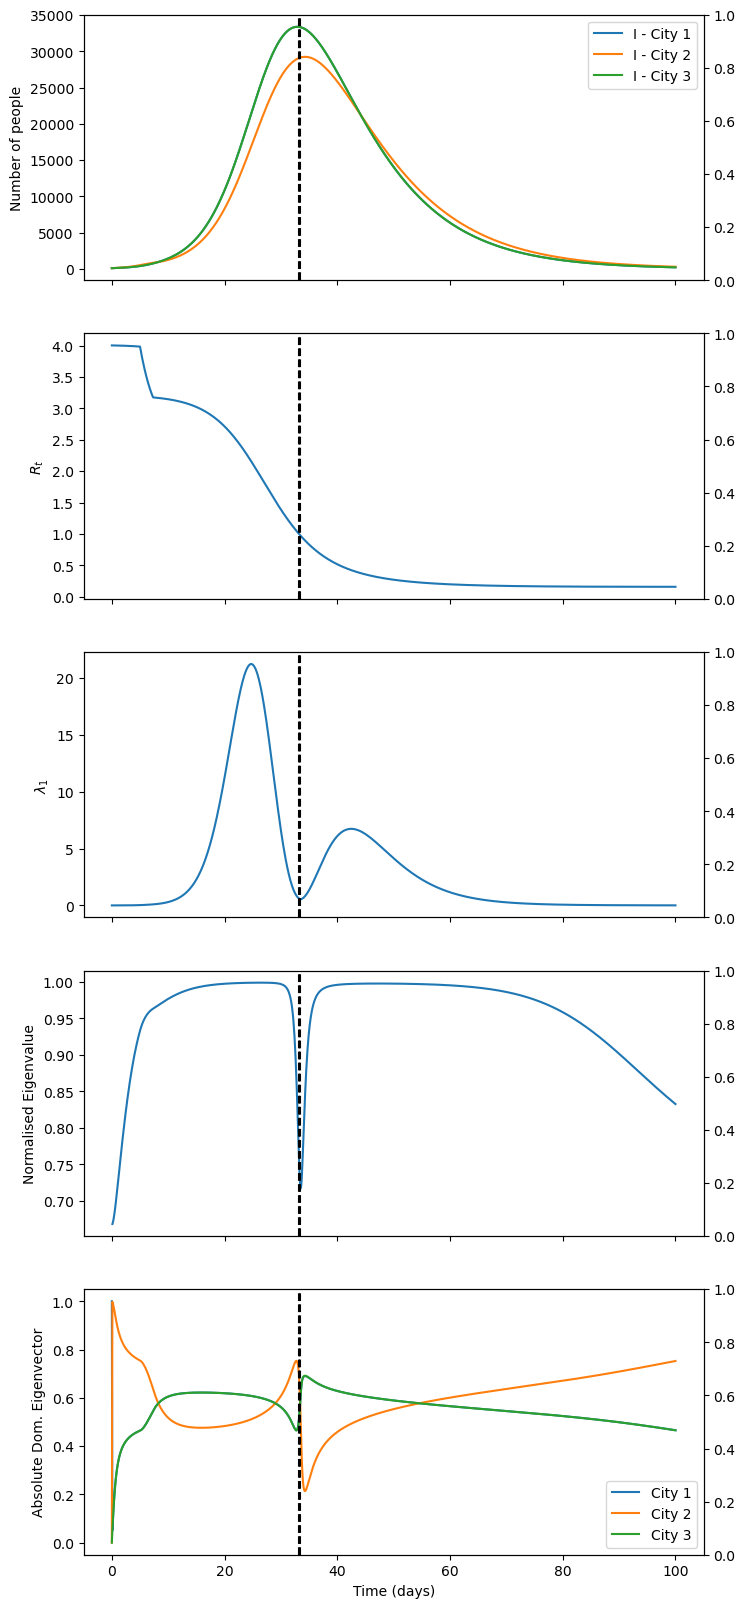

In [417]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,in_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(in_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,in_dec_eigvals)
axs[3].plot(ts,in_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Between cities

In [418]:
def betat(t):
    if t < 5:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.1*(t-5)*temp if (beta_matrix - 0.1*(t-5)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

ts = np.arange(0,100.1,0.1)
bet_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(bet_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
bet_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(bet_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/3183975776.py:12: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([480, 481, 482]),)

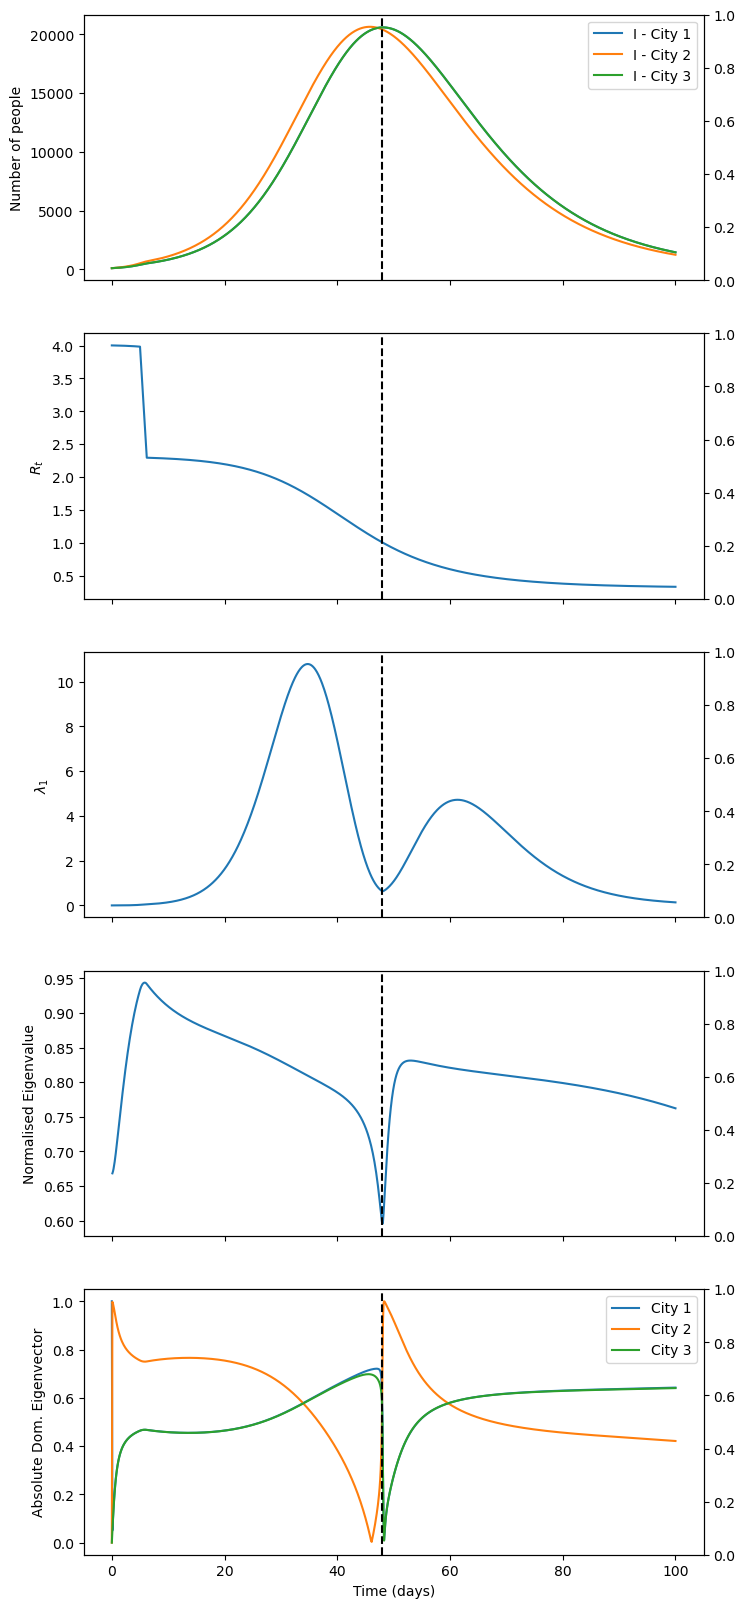

In [419]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,bet_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(bet_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,bet_dec_eigvals)
axs[3].plot(ts,bet_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## New variant

In [420]:
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
b_w_l = 0.05  # Transmission within each city
b_b_l = 0.025 # Transmission between cities
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu)

0.8532611778611298


1.3303954541400647

In [421]:
def betat(t):
    if t < 5:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],[0,0,1],[0,0,1]])
        return beta_matrix_low + 0.01*(t-5)*temp

ts = np.arange(0,100.1,0.1)
spur_var_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(spur_var_theory[i,6:])[3:,3:] for i in range(len(ts))]
spur_var_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(spur_var_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/3324469671.py:12: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([ 70, 483]),)

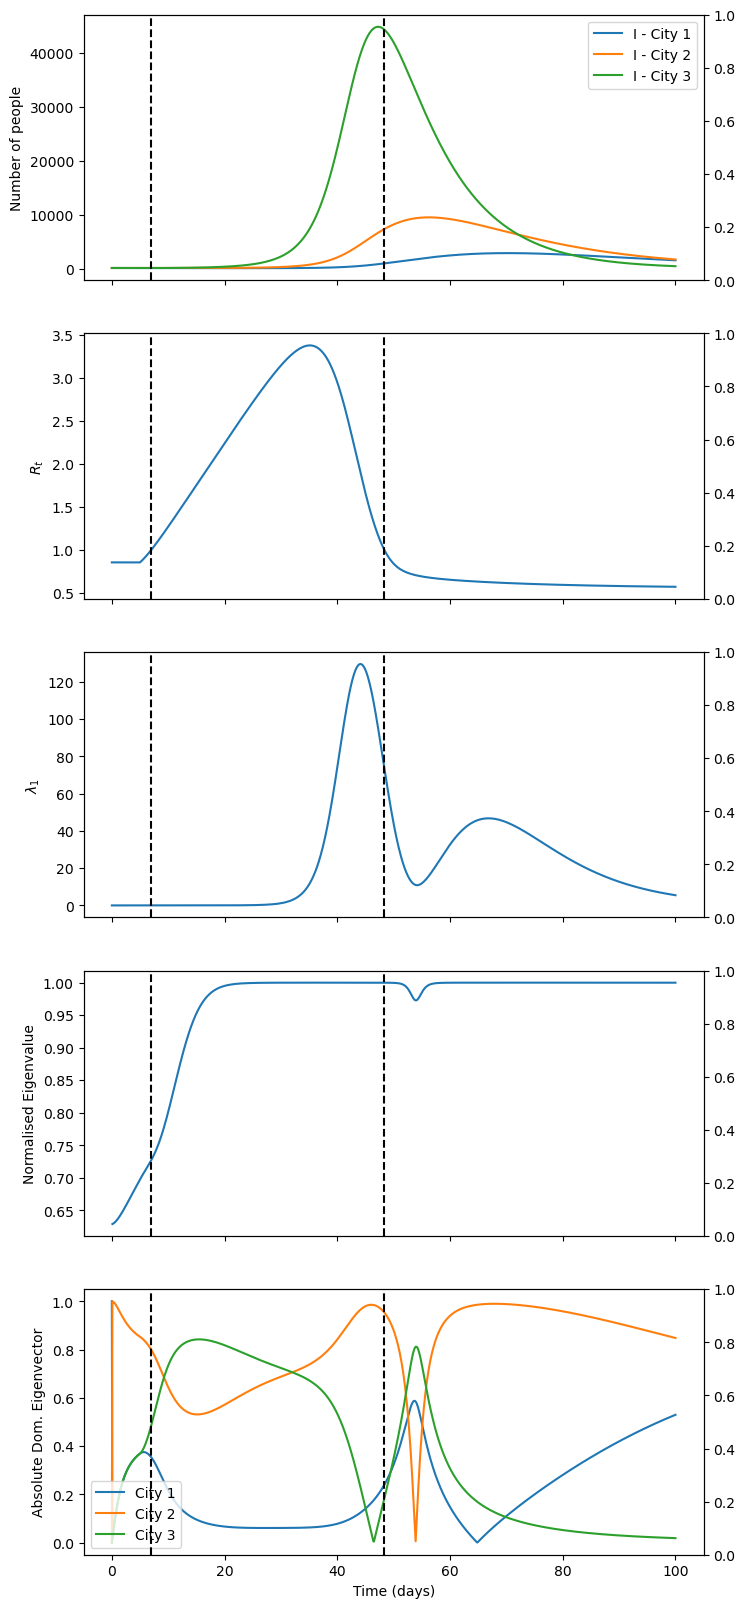

In [422]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,spur_var_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(spur_var_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,spur_var_eigvals)
axs[3].plot(ts,spur_var_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

# Slower NPIs

## Just b[1,1], full epidemic

In [423]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.05*(t-15)*temp if (beta_matrix - 0.05*(t-15)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])

ts = np.arange(0,100.1,0.1)
in_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(in_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
in_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(in_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_145949/2012071455.py:19: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([289, 290]),)

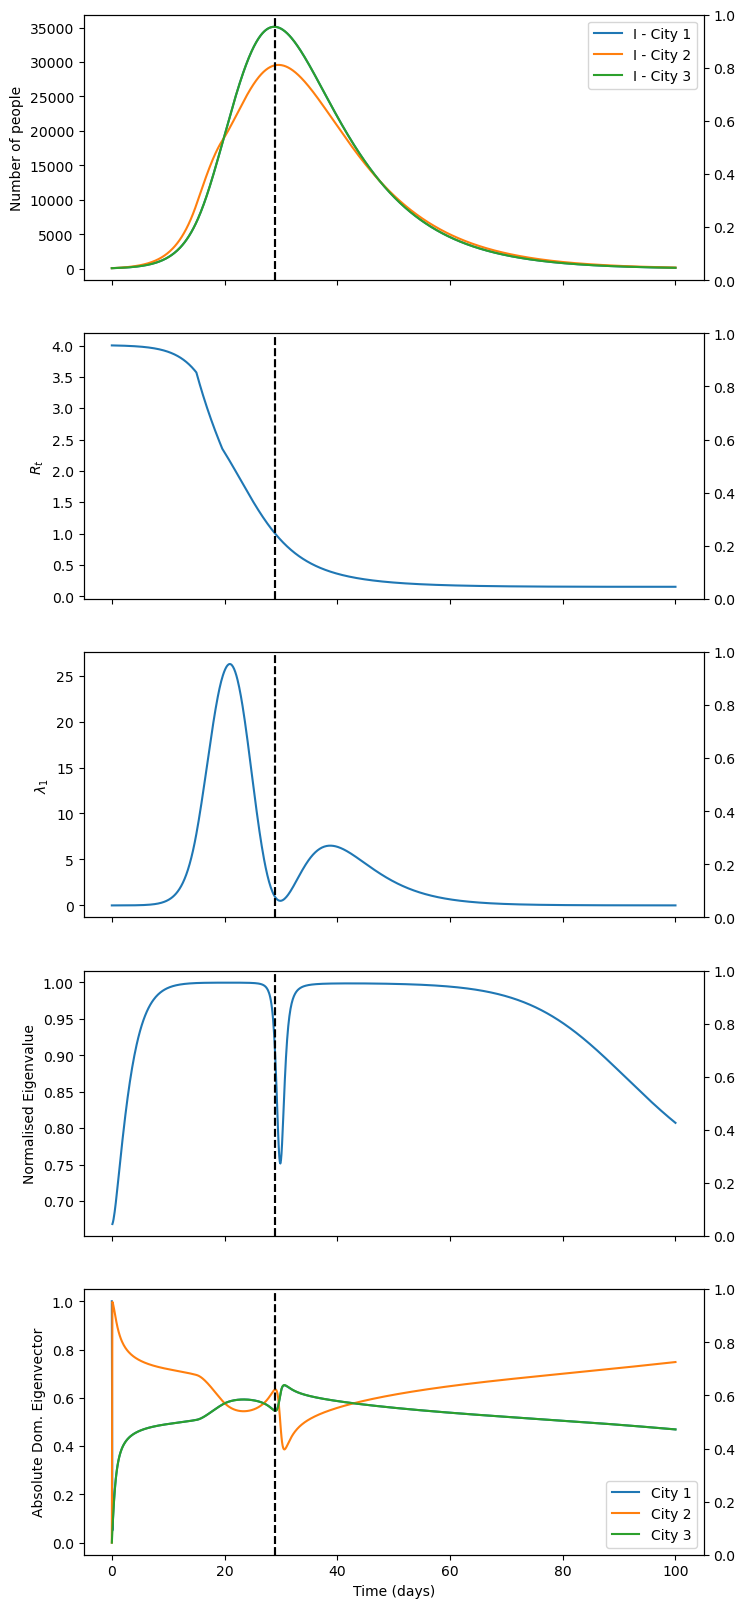

In [424]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,in_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(in_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,in_dec_eigvals)
axs[3].plot(ts,in_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Between cities

In [425]:
def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.05*(t-15)*temp if (beta_matrix - 0.05*(t-15)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

ts = np.arange(0,100.1,0.1)
bet_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(bet_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
bet_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(bet_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/2604553034.py:12: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([336, 337]),)

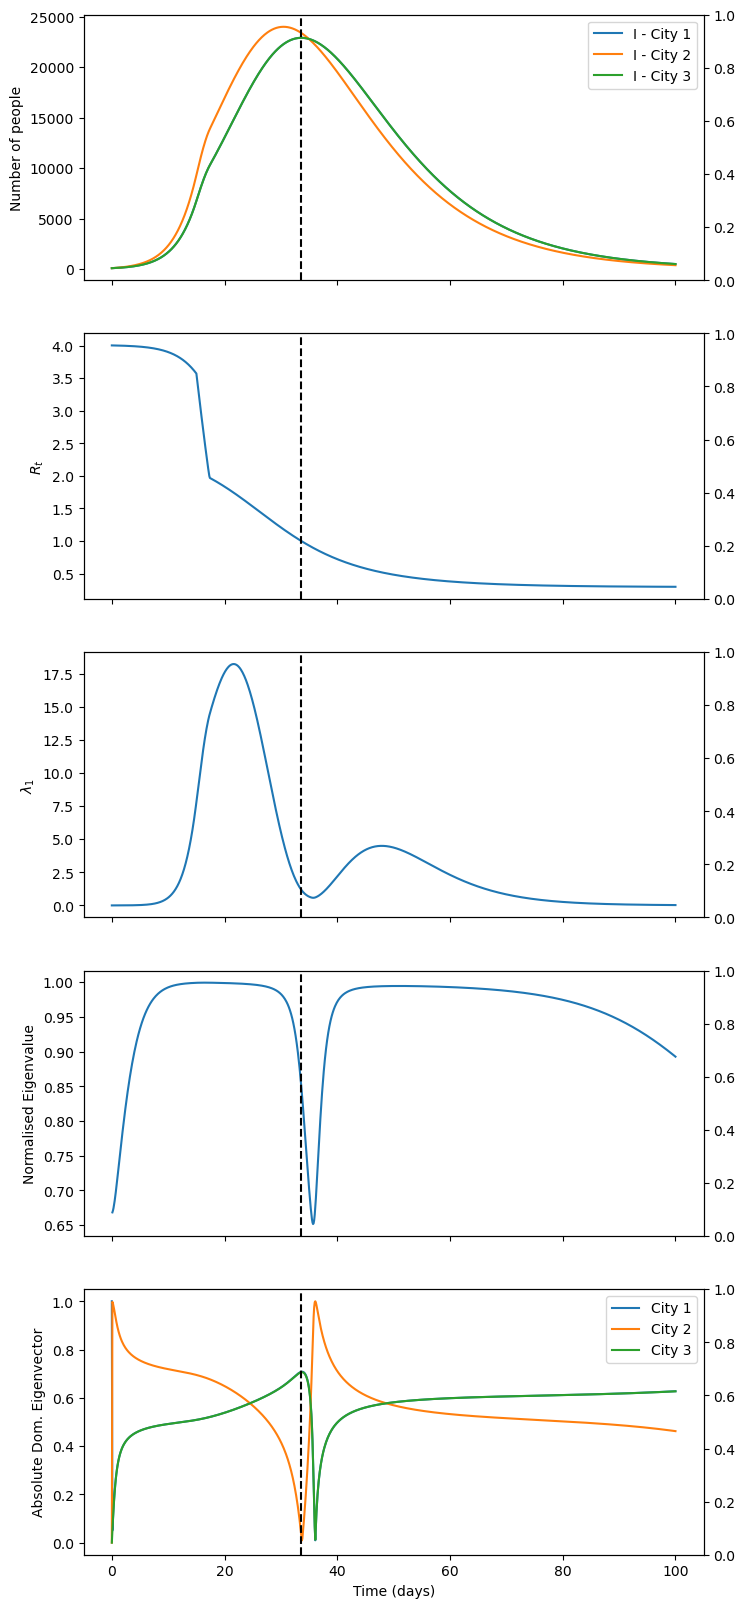

In [426]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,bet_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(bet_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,bet_dec_eigvals)
axs[3].plot(ts,bet_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## New variant

In [427]:
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
b_w_l = 0.05  # Transmission within each city
b_b_l = 0.025 # Transmission between cities
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu)

0.8532611778611298


1.3303954541400647

In [428]:
def betat(t):
    if t < 15:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],[0,0,1],[0,0,1]])
        return beta_matrix_low + 0.005*(t-15)*temp

ts = np.arange(0,100.1,0.1)
spur_var_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(spur_var_theory[i,6:])[3:,3:] for i in range(len(ts))]
spur_var_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(spur_var_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/1481693557.py:12: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([190, 191, 769]),)

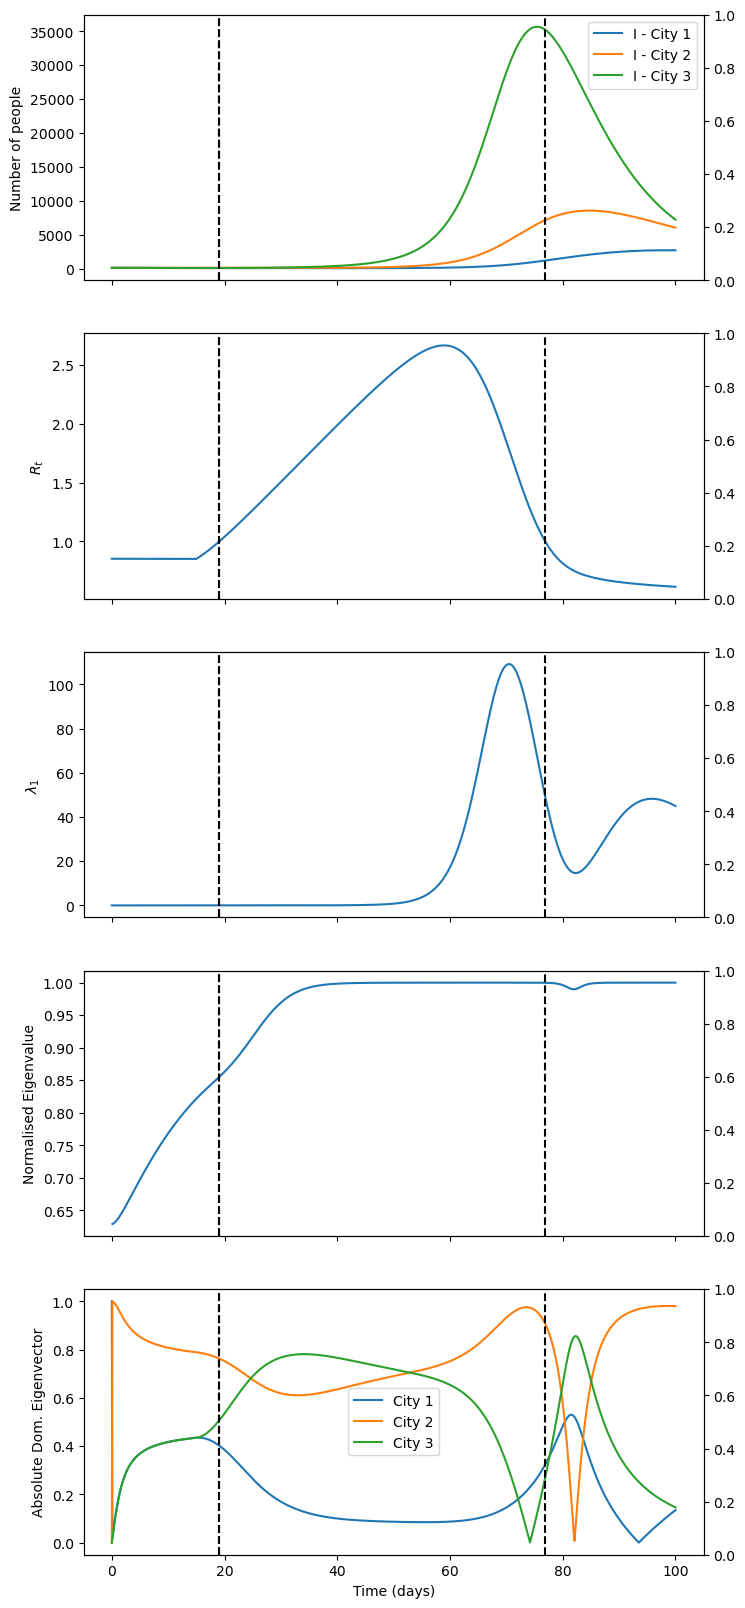

In [429]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,spur_var_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(spur_var_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,spur_var_eigvals)
axs[3].plot(ts,spur_var_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

# Different I0

## Constant $\beta$

In [430]:
# Parameters
N_cities = 3   # Number of cities
T_max = 100    # Maximum time
b_w = 0.231  # Transmission within each city
b_b = 0.12 # Transmission between cities
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
N_population = 100000  # Population per city

Ii = np.array([10,10,10])
Si = N_population - Ii

betat = lambda t: beta_matrix

ts = np.arange(0,100.1,0.1)
cst_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(cst_theory[i,6:])[3:,3:] for i in range(len(ts))]
cst_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
cst_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(cst_theory[i,:3]*beta_matrix)) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_145949/4258078303.py:20: RuntimeWarning: invalid value encountered in scalar divide
  cst_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([348, 349]),)

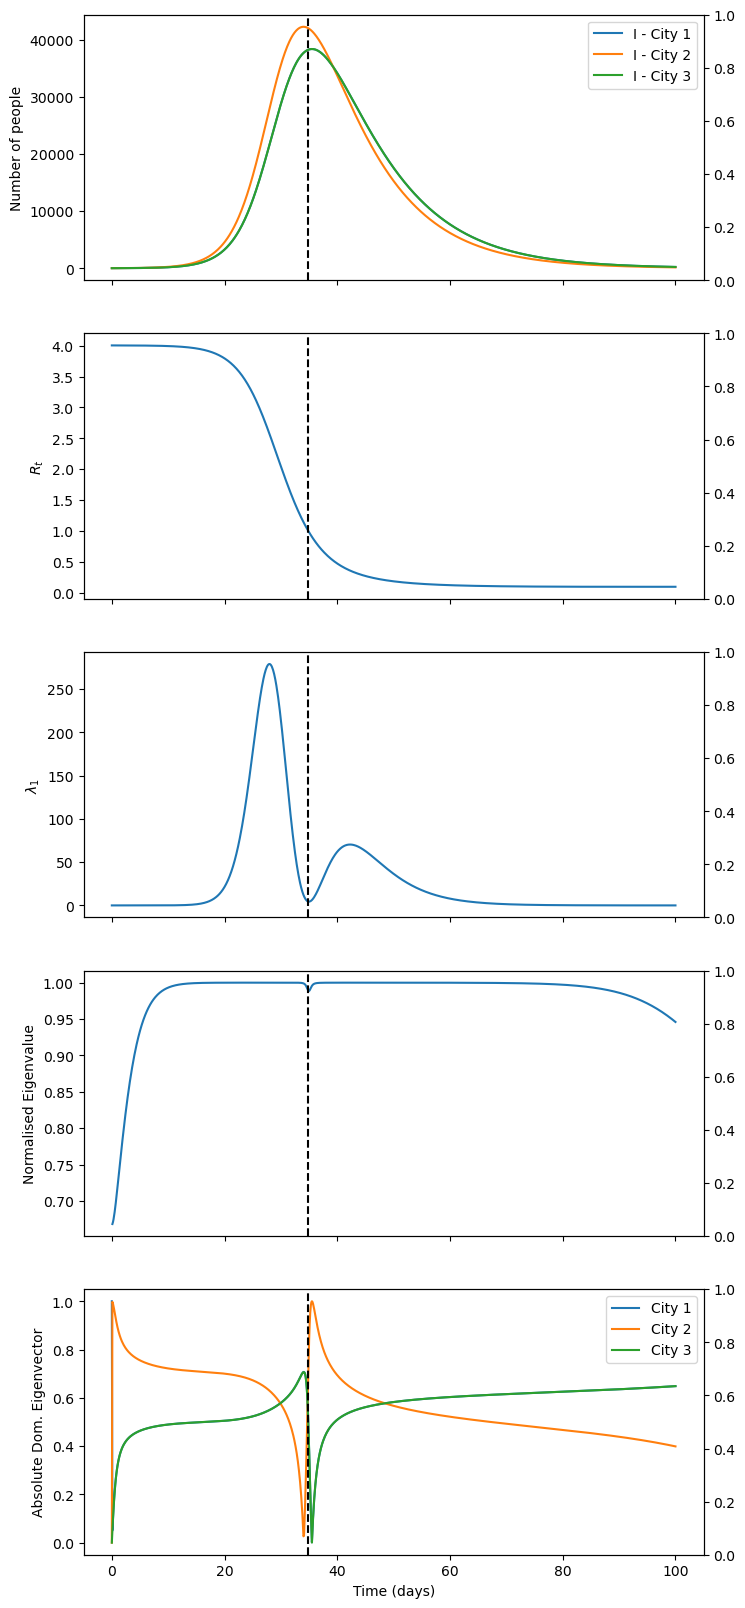

In [431]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,cst_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(cst_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,cst_eigvals)
axs[3].plot(ts,cst_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Just b[1,1], full epidemic

In [432]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])

ts = np.arange(0,100.1,0.1)
in_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(in_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
in_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
in_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(in_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.01)
crossings

/tmp/ipykernel_145949/241139304.py:19: RuntimeWarning: invalid value encountered in scalar divide
  in_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([400, 401]),)

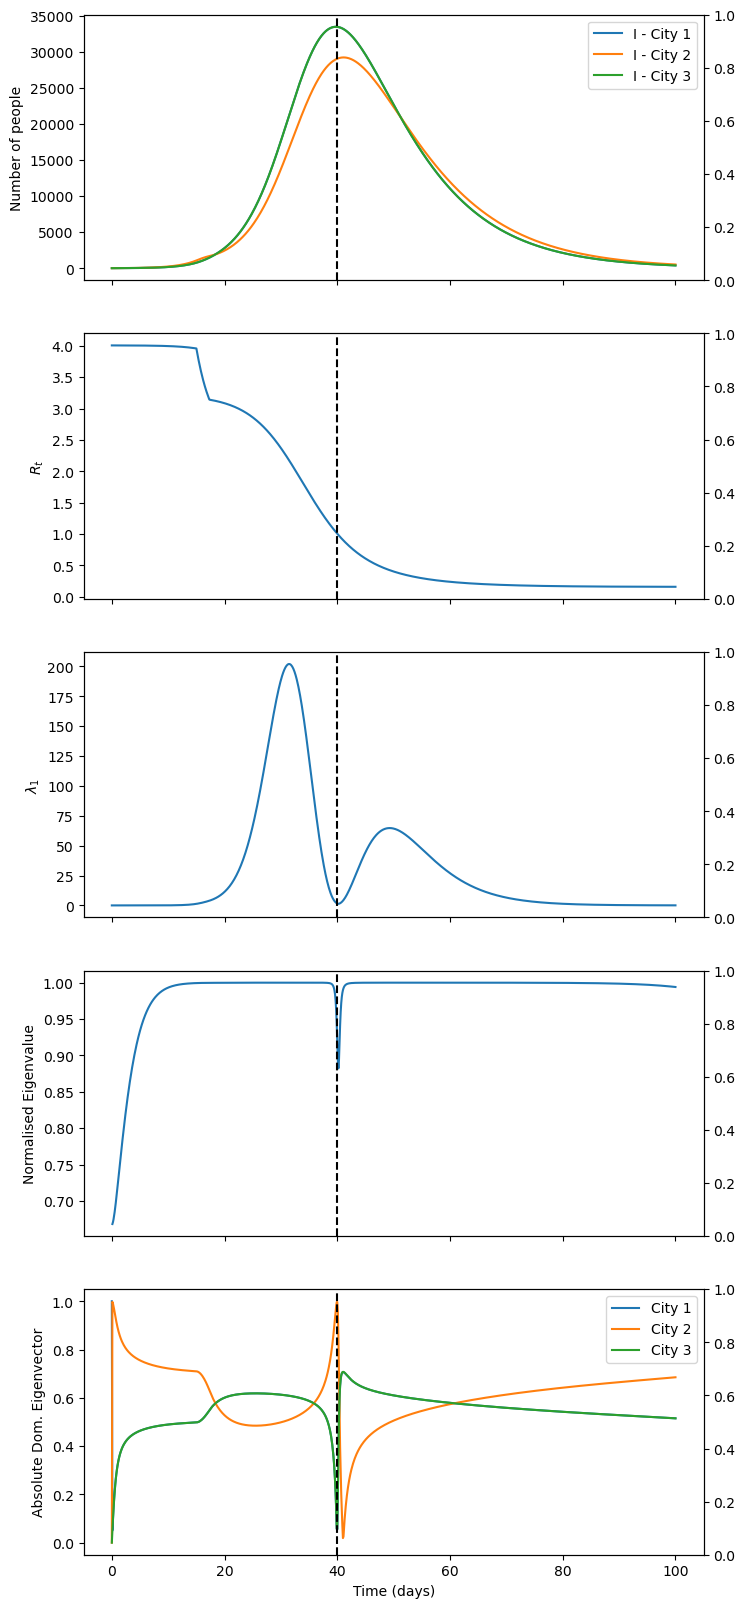

In [433]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,in_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(in_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,in_dec_eigvals)
axs[3].plot(ts,in_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## Between cities

In [434]:
def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

ts = np.arange(0,100.1,0.1)
bet_dec_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(bet_dec_theory[i,6:])[3:,3:] for i in range(len(ts))]
bet_dec_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
bet_dec_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(bet_dec_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.005)
crossings

/tmp/ipykernel_145949/1117251583.py:12: RuntimeWarning: invalid value encountered in scalar divide
  bet_dec_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([528, 529]),)

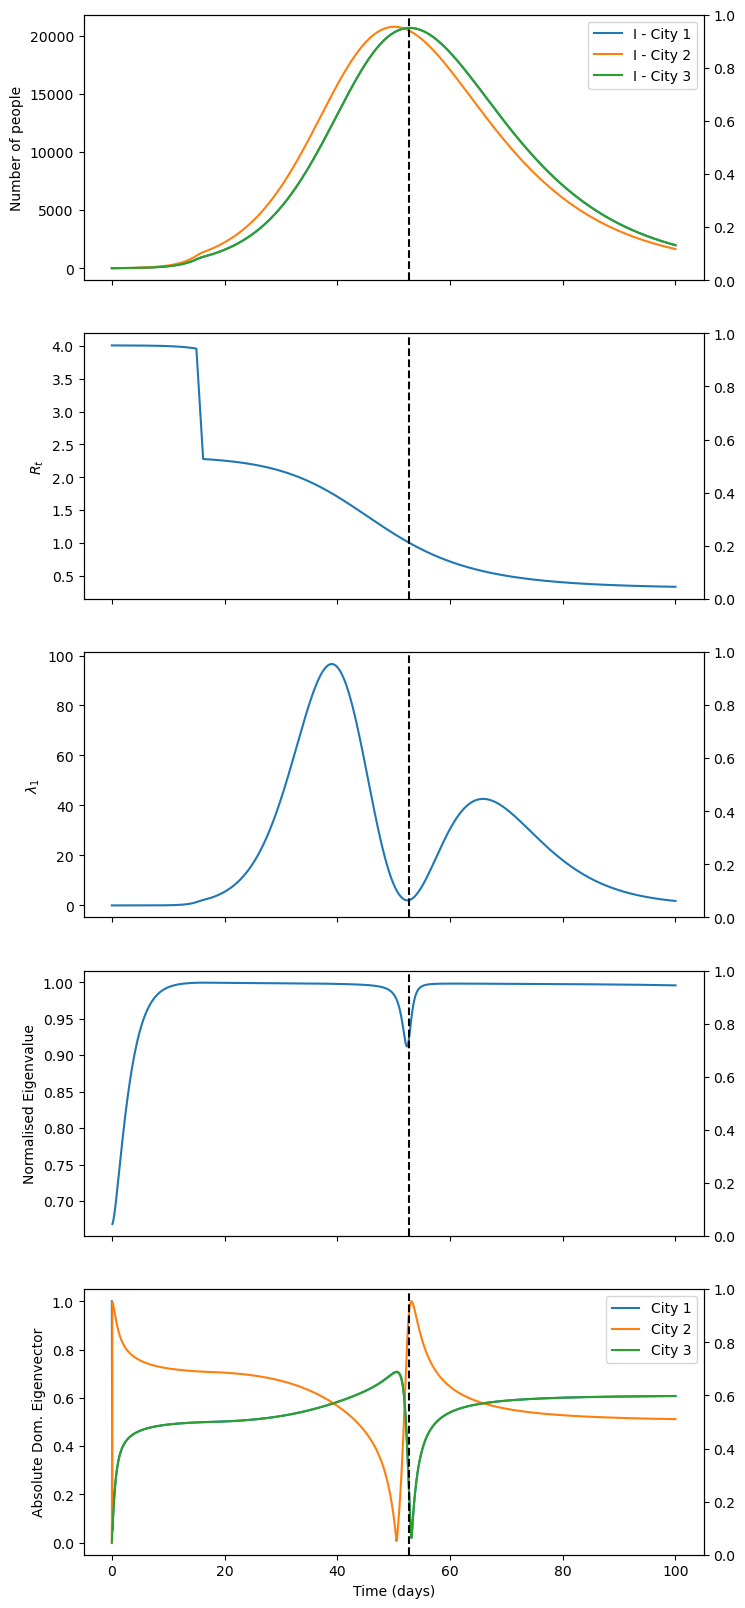

In [435]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,bet_dec_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(bet_dec_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,bet_dec_eigvals)
axs[3].plot(ts,bet_dec_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0][0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()

## New variant

In [436]:
gamma = 0.1    # Recovery rate
mu = 1/(80*365)     # Birth and death rate
b_w_l = 0.05  # Transmission within each city
b_b_l = 0.025 # Transmission between cities
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu)

0.8532611778611298


1.3303954541400647

In [441]:
def betat(t):
    if t < 15:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],[0,0,1],[0,0,1]])
        return beta_matrix_low + 0.01*(t-15)*temp

ts = np.arange(0,100.1,0.1)
spur_var_theory = odeint(meta_int,np.append(np.hstack((Si,Ii)),np.zeros(21)),ts,args=(betat,gamma,mu,N_population))
cov = [symmetric_matrix(spur_var_theory[i,6:])[3:,3:] for i in range(len(ts))]
spur_var_eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
spur_var_eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() for i in range(len(ts))])
Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(spur_var_theory[i,:3]*betat(ts[i]))) for i in range(len(ts))]
crossings = np.where(np.abs(np.array(Reff) - 1) <= 0.006)
crossings

/tmp/ipykernel_145949/995107079.py:12: RuntimeWarning: invalid value encountered in scalar divide
  spur_var_norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]


(array([170, 641]),)

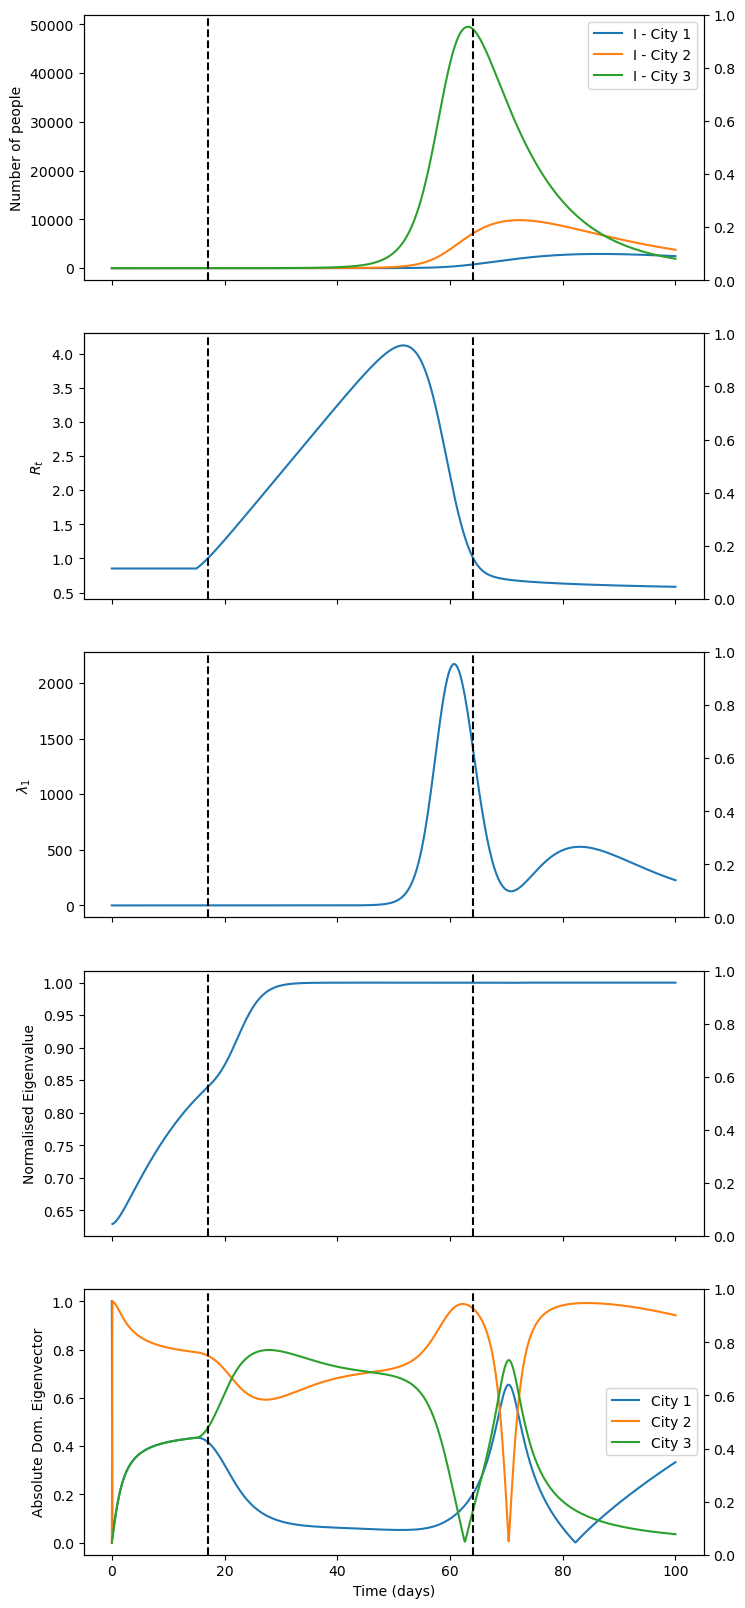

In [442]:
fig, axs = plt.subplots(nrows=5,ncols=1,figsize=(8,20),sharex=True)
for i in range(3):
    axs[0].plot(ts,spur_var_theory[:,i+3],label=f'I - City {i+1}')
    axs[4].plot(ts,np.abs(spur_var_eigvec[:,i]),label=f'City {i+1}')
axs[0].legend()
axs[4].legend()
axs[1].plot(ts,Reff)
axs[2].plot(ts,spur_var_eigvals)
axs[3].plot(ts,spur_var_norm_eigvals)
axs[0].set_ylabel('Number of people')
axs[1].set_ylabel(r'$R_t$')
axs[2].set_ylabel(r'$\lambda_1$')
axs[3].set_ylabel('Normalised Eigenvalue')
axs[4].set_ylabel('Absolute Dom. Eigenvector')
axs[-1].set_xlabel('Time (days)')
for i in range(len(axs)):
    ax = axs[i].twinx()
    ax.vlines(ts[crossings[0]],ymin=0,ymax=1,linestyles='--',colors='k')
    ax.set_ylim((0,1))
plt.show()